m_noise	D_total	Sil(Euc)	Sil(Cos)	Sil(PCA->2,Euc)
0	2	0.5490		0.7965		0.5490
2	4	0.4121		0.6452		0.5466
4	6	0.3332		0.5449		0.5462
8	10	0.2446		0.4205		0.5368
16	18	0.1611		0.2903		0.5269
32	34	0.0963		0.1803		0.5213
64	66	0.0535		0.1033		0.5107
128	130	0.0283		0.0555		0.4932
256	258	0.0148		0.0293		0.4691


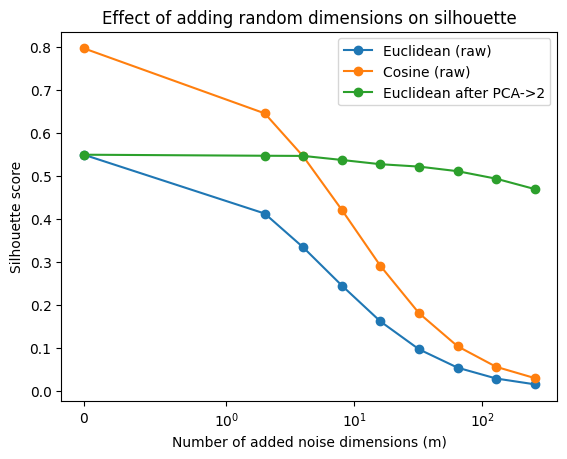

In [1]:
# Test: 2 “good” dimensions + m random noise dimensions → silhouette drops (Euclidean)
# Also show that PCA back to 2 dims recovers comparability.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

def make_two_gaussians(n_per=300, sep=3.0, sig_signal=1.0, seed=0):
    """
    Two spherical Gaussian clusters in 2D:
      Cluster 0 centered at (-sep/2, 0)
      Cluster 1 centered at (+sep/2, 0)
    """
    rng = np.random.default_rng(seed)
    mu0 = np.array([-sep/2, 0.0])
    mu1 = np.array([+sep/2, 0.0])
    X0 = rng.normal(loc=mu0, scale=sig_signal, size=(n_per, 2))
    X1 = rng.normal(loc=mu1, scale=sig_signal, size=(n_per, 2))
    X2 = np.vstack([X0, X1])
    y = np.array([0]*n_per + [1]*n_per)
    return X2, y, rng

def add_noise_dims(X2, m_noise, sig_noise, rng):
    """
    Append m_noise i.i.d. Gaussian noise dims to each sample.
    """
    if m_noise == 0:
        return X2
    N = X2.shape[0]
    noise = rng.normal(loc=0.0, scale=sig_noise, size=(N, m_noise))
    return np.hstack([X2, noise])

def evaluate_silhouettes(X, y, pca_k=2):
    """
    Compute:
      - Euclidean silhouette on raw X
      - Cosine silhouette (on X; cosine internally normalizes in sklearn)
      - Euclidean silhouette after PCA -> pca_k dims
    """
    # Raw Euclidean
    sil_euc = silhouette_score(X, y, metric="euclidean")

    # Cosine (sklearn cosine uses normalized dot products internally)
    sil_cos = silhouette_score(X, y, metric="cosine")

    # PCA to fixed k dims (global PCA for this dataset)
    if X.shape[1] > pca_k:
        Xk = PCA(n_components=pca_k, random_state=0).fit_transform(X)
    else:
        Xk = X
    sil_pca_euc = silhouette_score(Xk, y, metric="euclidean")

    return sil_euc, sil_cos, sil_pca_euc

def main():
    # --- Base: two good dims ---
    X2, y, rng = make_two_gaussians(
        n_per=400,
        sep=4.0,          # separation between cluster means
        sig_signal=1.0,   # within-cluster spread in the "good" dims
        seed=123
    )

    # --- Sweep number of noise dims ---
    noise_dims = [0, 2, 4, 8, 16, 32, 64, 128, 256]
    sig_noise = 1.0  # noise strength per added dim; try 0.5 / 1.0 / 2.0

    sil_euc_list = []
    sil_cos_list = []
    sil_pca_list = []

    for m in noise_dims:
        X = add_noise_dims(X2, m_noise=m, sig_noise=sig_noise, rng=rng)
        sil_euc, sil_cos, sil_pca = evaluate_silhouettes(X, y, pca_k=2)
        sil_euc_list.append(sil_euc)
        sil_cos_list.append(sil_cos)
        sil_pca_list.append(sil_pca)

    # --- Print a quick table ---
    print("m_noise\tD_total\tSil(Euc)\tSil(Cos)\tSil(PCA->2,Euc)")
    for m, se, sc, sp in zip(noise_dims, sil_euc_list, sil_cos_list, sil_pca_list):
        print(f"{m}\t{m+2}\t{se:.4f}\t\t{sc:.4f}\t\t{sp:.4f}")

    # --- Plot ---
    plt.figure()
    plt.plot(noise_dims, sil_euc_list, marker="o", label="Euclidean (raw)")
    plt.plot(noise_dims, sil_cos_list, marker="o", label="Cosine (raw)")
    plt.plot(noise_dims, sil_pca_list, marker="o", label="Euclidean after PCA->2")
    plt.xscale("symlog", linthresh=1)  # readable for 0,2,4,...; optional
    plt.xlabel("Number of added noise dimensions (m)")
    plt.ylabel("Silhouette score")
    plt.title("Effect of adding random dimensions on silhouette")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

m_noise	MeanCenterDist	Std
0		3.9875		0.1524
2		4.0138		0.1322
4		4.0006		0.1298
8		4.0019		0.1413
16		4.0187		0.1145
32		4.0562		0.1349
64		4.1462		0.1635
128		4.3076		0.1375


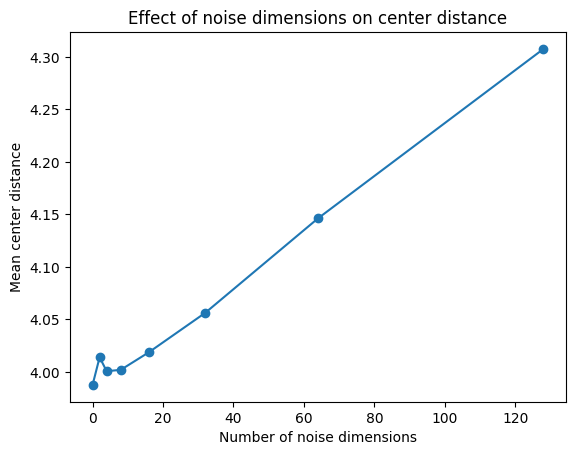

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_center_distance(
    n_per=200,
    sep=4.0,
    sig_signal=1.0,
    sig_noise=1.0,
    noise_dims_list=[0, 2, 4, 8, 16, 32, 64, 128],
    M=50,
    seed=0
):
    rng = np.random.default_rng(seed)

    results = []

    for m in noise_dims_list:
        dists = []

        for _ in range(M):
            # --- generate signal ---
            mu0 = np.array([-sep/2, 0.0])
            mu1 = np.array([+sep/2, 0.0])

            X0 = rng.normal(mu0, sig_signal, size=(n_per, 2))
            X1 = rng.normal(mu1, sig_signal, size=(n_per, 2))

            # --- add noise dims ---
            if m > 0:
                N0 = rng.normal(0, sig_noise, size=(n_per, m))
                N1 = rng.normal(0, sig_noise, size=(n_per, m))
                X0 = np.hstack([X0, N0])
                X1 = np.hstack([X1, N1])

            # --- sample subset (optional) ---
            idx0 = rng.choice(n_per, size=n_per//2, replace=False)
            idx1 = rng.choice(n_per, size=n_per//2, replace=False)

            center0 = X0[idx0].mean(axis=0)
            center1 = X1[idx1].mean(axis=0)

            d = np.linalg.norm(center0 - center1)
            dists.append(d)

        results.append((m, np.mean(dists), np.std(dists)))

    return results

results = simulate_center_distance()

print("m_noise\tMeanCenterDist\tStd")
for m, mean_d, std_d in results:
    print(f"{m}\t\t{mean_d:.4f}\t\t{std_d:.4f}")

# Plot
noise_dims = [r[0] for r in results]
means = [r[1] for r in results]

plt.plot(noise_dims, means, marker='o')
plt.xlabel("Number of noise dimensions")
plt.ylabel("Mean center distance")
plt.title("Effect of noise dimensions on center distance")
plt.show()

# Note
This simple experiment shows that if we have only few dimensions that are carrying useful information, while other dimensions carry no information but noise, it will negatively affect silhouette score. In contrast, distance will still increase, despite having only irrelevant dimensions. This should explain why we see lower silhouette score performance despite larger hidden dimensions. 